# Case study — a multi-modal recommender vs. a popularity baseline

**Scenario.** The storefront's *suggested-product* surface runs a simple popularity-by-category recommender. The commercial stakeholder finds it generic; the Product Manager and Senior AI Engineer agree to replace it with a multi-modal model and measure the result honestly. Full contract: [`docs/requirement.md`](../docs/requirement.md).

**Honesty boundary.** No interaction data exists, so revenue/engagement are motivation only. Success is measured with offline ranking metrics against a content-based relevance proxy (same `articleType` + `gender`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

summary = json.load(open(ROOT / 'artifacts' / 'reco_metrics_summary.json'))
bm, pm = summary['baseline']['metrics'], summary['proposed']['metrics']
ks = summary['ks']
f"{summary['n_queries']} queries | category signal: {summary['category_signal']} | "
f"relevance: {summary['relevance_proxy']}"

'relevance: same articleType and gender (content-based; no interaction data)'

## Results: baseline vs. hybrid

In [2]:
rows = []
for fam in ['precision', 'recall', 'ndcg']:
    for k in ks:
        m = f'{fam}@{k}'
        rows.append({'metric': m, 'baseline': bm[m]['mean'], 'hybrid': pm[m]['mean']})
tab = pd.DataFrame(rows)
tab['lift_%'] = ((tab.hybrid - tab.baseline) / tab.baseline * 100).round(0)
tab.round(3)

,metric,baseline,hybrid,lift_%
0,precision@5,0.325,0.898,176.0
1,precision@10,0.308,0.873,184.0
2,recall@5,0.003,0.022,636.0
3,recall@10,0.006,0.037,515.0
4,ndcg@5,0.320,0.906,183.0
5,ndcg@10,0.309,0.888,187.0


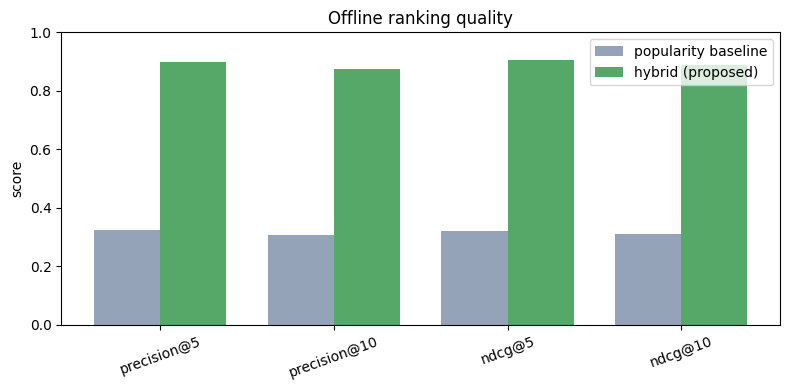

In [3]:
metrics = [f'precision@{k}' for k in ks] + [f'ndcg@{k}' for k in ks]
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [bm[m]['mean'] for m in metrics], w, label='popularity baseline', color='#94a3b8')
ax.bar(x + w/2, [pm[m]['mean'] for m in metrics], w, label='hybrid (proposed)', color='#55A868')
ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=20); ax.set_ylim(0, 1)
ax.set_ylabel('score'); ax.set_title('Offline ranking quality'); ax.legend()
plt.tight_layout()

**The hybrid clears the acceptance bar decisively.** Three honest reads:

- **The margin survived removing a leak.** A development version indexed the `articleType` field verbatim — the relevance label itself — inflating precision@5 to 0.97. Excluding the relevance-defining fields from the similarity text keeps the reported number honest rather than circular.
- **Recall is low by construction.** Each query has tens-to-hundreds of proxy-relevant items while k ≤ 10, so recall@10 is near its natural ceiling; precision and NDCG are the meaningful metrics.
- **This is a content-recovery result, not a preference result.** It shows the hybrid recovers fine-grained catalog structure the baseline ignores; a preference lift would need real interaction data.

## How it works — two signals, one agent

A local tool-calling agent turns either input into recommendations: a **text description** → `search_similar_products`; an **attached photo** → `classify_product` (image → subcategory) then a category-scoped search. The similarity signal is sentence-transformers embeddings (`all-MiniLM-L6-v2`, cosine) — the same model offline and in the live Chroma index.

We surface the **grounded retrieval** — the actual catalog items the search tool returned — rather than the model's free-text prose. A small local model can paraphrase loosely, so the trustworthy recommendation is what the tool retrieved, which the data contract keeps inspectable.

In [4]:
# Live agent demo (needs Ollama + llama3.1:8b and the Chroma index).
try:
    from src.agent import chat
    res = chat('blue running shoes for men')
    print('Tools the agent chose:', [t['tool'] for t in res['tool_trace']])
    print('\nGrounded recommendations (from search_similar_products):')
    for t in res['tool_trace']:
        if t['tool'] == 'search_similar_products':
            for item in t['result']:
                print(f"  - {item['productDisplayName']}  ({item['articleType']} / {item['gender']})")
except Exception as exc:
    print(f'Agent demo skipped ({type(exc).__name__}: {exc}).')
    print('Run `ollama pull llama3.1:8b` and build the index to execute this cell.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Tools the agent chose: ['search_similar_products']

Grounded recommendations (from search_similar_products):
  - ADIDAS Men Blue Talus Runner Sports Shoes  (Sports Shoes / Men)
  - ADIDAS Men Runner White & Blue Sports Shoes  (Sports Shoes / Men)
  - ID Men Blue Casual Shoes  (Casual Shoes / Men)
  - ID Men Blue Casual Shoes  (Casual Shoes / Men)
  - Nike Men Free Run Blue Sports Shoes  (Sports Shoes / Men)
  - Nike Men Blue Flyclave LTR Casual Shoes  (Casual Shoes / Men)
  - Vans Men Blue 106 Vulcanized Shoes  (Casual Shoes / Men)
  - ADIDAS Men Sports Blue Sports Shoes  (Sports Shoes / Men)
  - Nike Men Liteforce Navy Blue Casual Shoes  (Casual Shoes / Men)
  - Newfeel Men Decathlon Blue Casual Shoes  (Casual Shoes / Men)


## Prescriptive read (Pillar 4)

Ship the hybrid behind the suggested-product surface with the popularity baseline as a fallback. Because the offline win is a content-recovery proxy, the honest next step before claiming business value is an **online A/B test** on the revenue/engagement KPIs that motivated the work.

**OKRs.** *Objective* — make suggested-product genuinely useful. *Key Results* — (1) hybrid live behind a feature flag; (2) A/B test instrumented on click-through and add-to-cart; (3) a calibrated relevance threshold for the recommendation cutoff.

## Appendix — the classification sub-experiment

Which image model feeds the recommender? The earlier study tested whether adding structured attributes to the photo improves subcategory classification. It does not — the **image-only baseline wins on every metric**, so it is the signal the recommender ships.

In [5]:
b = json.load(open(ROOT / 'artifacts' / 'metrics_baseline_summary.json'))
p = json.load(open(ROOT / 'artifacts' / 'metrics_proposed_summary.json'))
pd.DataFrame({
    'image-only baseline': [b['accuracy']['mean'], b['macro_f1']['mean'], b['weighted_f1']['mean']],
    'image + attributes': [p['accuracy']['mean'], p['macro_f1']['mean'], p['weighted_f1']['mean']],
}, index=['accuracy', 'macro_f1', 'weighted_f1']).round(3)

,image-only baseline,image + attributes
accuracy,0.931,0.883
macro_f1,0.854,0.803
weighted_f1,0.935,0.897
